# Assignment 3: CNN-LSTM, ViT, and Object Tracking
## Section 2: Vision Transformer
### Prasanna Paithankar (21CS30065)

6th April 2026

In [1]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [2]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0, (
            "Embedding dimension must be divisible by number of heads"
        )

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)

        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, N, C = x.shape

        q = self.q_proj(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = torch.softmax(scores, dim=-1)

        attn_output = torch.matmul(attn_weights, v)

        attn_output = attn_output.transpose(1, 2).contiguous().reshape(B, N, C)

        return self.out_proj(attn_output)


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim=256):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.mhsa = MultiHeadSelfAttention(embed_dim, num_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim), nn.GELU(), nn.Linear(mlp_dim, embed_dim)
        )

    def forward(self, x):
        x = x + self.mhsa(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=128,
        num_heads=4,
        num_layers=2,
    ):
        super().__init__()

        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.patch_embed = nn.Conv2d(
            in_channels, embed_dim, kernel_size=patch_size, stride=patch_size
        )

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))

        self.blocks = nn.ModuleList(
            [TransformerEncoderBlock(embed_dim, num_heads) for _ in range(num_layers)]
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embed

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        cls_output = x[:, 0]
        return self.head(cls_output)

In [3]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

BATCH_SIZE = 128
LR = 1e-3
EPOCHS = 25

transform_train = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]
)

transform_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]
)

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

model = VisionTransformer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

epoch_losses = []

print("Starting Training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(trainloader.dataset)
    epoch_losses.append(epoch_loss)

    print(f"Epoch [{epoch + 1}/{EPOCHS}], Loss: {epoch_loss:.4f}")

Using device: cpu


100%|██████████| 170M/170M [01:13<00:00, 2.32MB/s] 


Starting Training...
Epoch [1/25], Loss: 1.7633
Epoch [2/25], Loss: 1.5235
Epoch [3/25], Loss: 1.4264
Epoch [4/25], Loss: 1.3564
Epoch [5/25], Loss: 1.3046
Epoch [6/25], Loss: 1.2544
Epoch [7/25], Loss: 1.2180
Epoch [8/25], Loss: 1.1637
Epoch [9/25], Loss: 1.1224
Epoch [10/25], Loss: 1.0831
Epoch [11/25], Loss: 1.0487
Epoch [12/25], Loss: 1.0178
Epoch [13/25], Loss: 0.9898
Epoch [14/25], Loss: 0.9642
Epoch [15/25], Loss: 0.9401
Epoch [16/25], Loss: 0.9132
Epoch [17/25], Loss: 0.9027
Epoch [18/25], Loss: 0.8809
Epoch [19/25], Loss: 0.8648
Epoch [20/25], Loss: 0.8508
Epoch [21/25], Loss: 0.8414
Epoch [22/25], Loss: 0.8278
Epoch [23/25], Loss: 0.8133
Epoch [24/25], Loss: 0.8015
Epoch [25/25], Loss: 0.7910


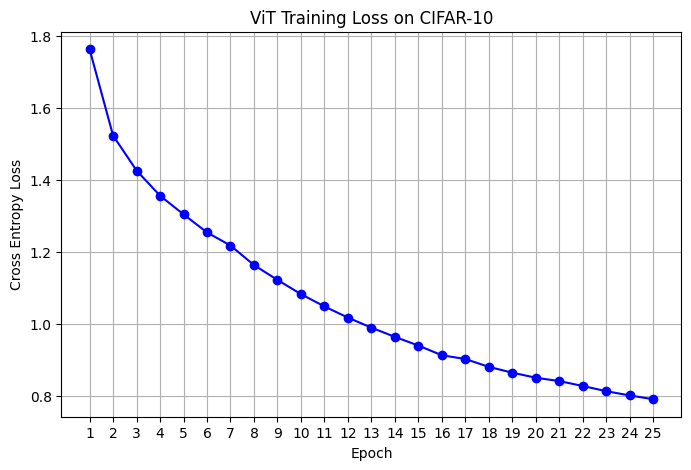

Starting Evaluation...
Final Test Accuracy on CIFAR-10: 70.86%


In [4]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), epoch_losses, marker="o", linestyle="-", color="b")
plt.title("ViT Training Loss on CIFAR-10")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True)
plt.xticks(range(1, EPOCHS + 1))
plt.show()

print("Starting Evaluation...")
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"=========================================")
print(f"Final Test Accuracy on CIFAR-10: {test_accuracy:.2f}%")
print(f"=========================================")

***